In [48]:
# All the imports
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

#Load mallcustomers
data = pd.read_csv('mallcustomers.csv')


In [49]:
# Problem #1--Preprocessing
# Removing commas from numerical data stored as strings, removing USD from string data, converting numerical string data to integer type
data['Income'] = (
    data['Income']
        .str.replace(',', '', regex=False)
        .str.replace(' USD', '', regex=False)
        .astype(int)
)
print(data.dtypes)

CustomerID       int64
Gender             str
Age              int64
Income           int64
SpendingScore    int64
dtype: object


In [50]:
# Problem #2--Preprocessing
# Eliminating customerid

# Keeping a copy of the original dataframe for later analysis
data_original = data.copy()

data = data.drop(columns=['CustomerID'])

print(data.columns)

Index(['Gender', 'Age', 'Income', 'SpendingScore'], dtype='str')


In [51]:
# Problem #3--Preprocessing
# Standardizing scales

# Summary statistics for Income and SpendingScore
print(data[["Income", "SpendingScore"]].describe())
X = data[["Income", "SpendingScore"]].values

# Normalizing Z-score
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

              Income  SpendingScore
count     200.000000     200.000000
mean    60560.000000      50.200000
std     26264.721165      25.823522
min     15000.000000       1.000000
25%     41500.000000      34.750000
50%     61500.000000      50.000000
75%     78000.000000      73.000000
max    137000.000000      99.000000


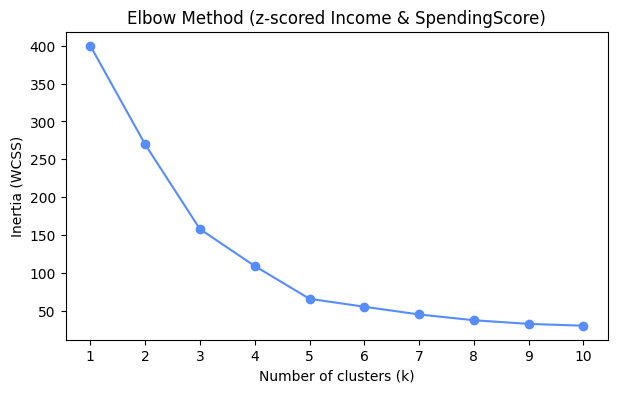

In [52]:
# Problem #4--Data clustering using Elbow Method and final k-means
inertias = []
k_values = range(1,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Xz)
    inertias.append(kmeans.inertia_)

# Plotting elbow curve
plt.figure(figsize=(7, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method (z-scored Income & SpendingScore)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(list(k_values))
plt.show()



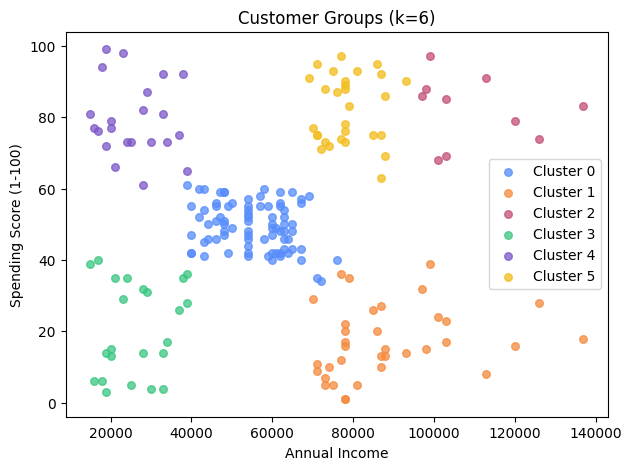

In [53]:
# Setting the final k after inspecting the elbow plot
k_final = 6  #I chose this number after looking at the elbow plot.

# Fitting final k-means model with random_state=42 for reproducibility
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(Xz)

# Attaching clusters to data and data_original
data["Cluster"] = clusters
data_original["Cluster"] = clusters

# Visualizing clusters in original scale (Income vs SpendingScore
plt.figure(figsize=(7, 5))
for c in range(k_final):
    subset = data_original[data_original["Cluster"] == c]
    plt.scatter(subset["Income"], subset["SpendingScore"], s=30, alpha=0.75,
                label=f"Cluster {c}")
plt.title(f"Customer Groups (k={k_final})")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [55]:
# Problem 5 (Evaluating the Clusters):
# 1) Giving names to clusters based on their location on the plot.
# 2) Creating dummy variables Male/Female for Gender.
# 3) Computing gender distribution + mean age per cluster.

# Creating gender dummy variables
data_original["Male"] = (data_original["Gender"] == "Male").astype(int)
data_original["Female"] = (data_original["Gender"] == "Female").astype(int)

# Clustering centers in original units for naming

centers_z = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_z)

centers_df = pd.DataFrame(
    centers_original, columns=["Income_center", "SpendingScore_center"]
)
centers_df["Cluster"] = range(k_final)

print("\n=== Cluster Centers (original units) ===")
print(centers_df.sort_values("Income_center"))



=== Cluster Centers (original units) ===
   Income_center  SpendingScore_center  Cluster
4   25727.272727             79.363636        4
3   26304.347826             20.913043        3
0   55296.296296             49.518519        0
5   78551.724138             82.172414        5
1   88200.000000             17.114286        1
2  109700.000000             82.000000        2


In [56]:
# Creating simple descriptive names based on center positions.
# Labeling income as low, mid and high and spending as low, mid, and high using tertiles

income_tertiles = np.quantile(centers_df["Income_center"], [1/3, 2/3])
spend_tertiles = np.quantile(centers_df["SpendingScore_center"], [1/3, 2/3])


def level(value, cutpoints):
    if value <= cutpoints[0]:
        return "Low"
    elif value <= cutpoints[1]:
        return "Mid"
    else:
        return "High"


cluster_name_map = {}
for _, row in centers_df.iterrows():
    inc_level = level(row["Income_center"], income_tertiles)
    sp_level = level(row["SpendingScore_center"], spend_tertiles)

    if inc_level == "Low" and sp_level == "Low":
        name = "Low Income / Low Spend (Low Engagement)"
    elif inc_level == "Low" and sp_level == "High":
        name = "Low Income / High Spend (Enthusiastic Budget Shoppers)"
    elif inc_level == "High" and sp_level == "Low":
        name = "High Income / Low Spend (Value-Conscious)"
    elif inc_level == "High" and sp_level == "High":
        name = "High Income / High Spend (Premium Customers)"
    else:
        name = f"{inc_level} Income / {sp_level} Spend"

    cluster_name_map[int(row["Cluster"])] = name

data_original["ClusterName"] = data_original["Cluster"].map(cluster_name_map)


print("\n=== Cluster Names ===")
for c in sorted(cluster_name_map.keys()):
    print(f"Cluster {c}: {cluster_name_map[c]}")



=== Cluster Names ===
Cluster 0: Mid Income / Mid Spend
Cluster 1: High Income / Low Spend (Value-Conscious)
Cluster 2: High Income / High Spend (Premium Customers)
Cluster 3: Low Income / Low Spend (Low Engagement)
Cluster 4: Low Income / Mid Spend
Cluster 5: Mid Income / High Spend


In [57]:
# This prints the demographic summary per cluster (gender distribution and mean age)

demo_summary = data_original.groupby(["Cluster", "ClusterName"]).agg(
    Count=("Cluster", "count"),
    MeanAge=("Age", "mean"),
    MaleCount=("Male", "sum"),
    FemaleCount=("Female", "sum"),
    MalePct=("Male", "mean"),
    FemalePct=("Female", "mean")
).reset_index()


demo_summary["MalePct"] = (demo_summary["MalePct"] * 100).round(1)
demo_summary["FemalePct"] = (demo_summary["FemalePct"] * 100).round(1)
demo_summary["MeanAge"] = demo_summary["MeanAge"].round(1)

print("\n=== Demographics by Cluster (Gender Distribution + Mean Age) ===")
print(demo_summary)



=== Demographics by Cluster (Gender Distribution + Mean Age) ===
   Cluster                                   ClusterName  Count  MeanAge  \
0        0                        Mid Income / Mid Spend     81     42.7   
1        1     High Income / Low Spend (Value-Conscious)     35     41.1   
2        2  High Income / High Spend (Premium Customers)     10     32.2   
3        3       Low Income / Low Spend (Low Engagement)     23     45.2   
4        4                        Low Income / Mid Spend     22     25.3   
5        5                       Mid Income / High Spend     29     32.9   

   MaleCount  FemaleCount  MalePct  FemalePct  
0         33           48     40.7       59.3  
1         19           16     54.3       45.7  
2          4            6     40.0       60.0  
3          9           14     39.1       60.9  
4          9           13     40.9       59.1  
5         14           15     48.3       51.7  
